### Import libraries & load cleaned data

In [4]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/sample_car_contracts.csv")  
df.head()


,id,customer_name,email_id,phone_no,contract_type,vehicle_type,monthly_emi,interest_rate,tenure_months,clause_summary,risk_flag,issue_type,recommended_action
0,1,Arjun Mehta,arjun.mehta@example.com,9876543210,New Car Loan,Sedan,13450,8.5,60,Includes prepayment penalty clause; mandatory ...,Low,NaN,No action needed; review terms annually
1,2,Pooja Reddy,pooja.reddy@example.com,9123456780,Used Car Loan,Hatchback,8900,10.2,48,Warranty disclaimer clause; repossession claus...,Medium,Short notice period,Renegotiate notice duration to 30 days
2,3,Rahul Sharma,rahul.sharma@example.com,9988776655,Electric Vehicle Loan,EV SUV,15200,7.8,72,Battery degradation liability unclear; high pr...,High,Ambiguous liability,Clarify battery warranty with dealership
3,4,Neha Kapoor,neha.kapoor@example.com,9090909090,Refinance Loan,Sedan,11200,9.1,36,Interest reset clause; floating rate adjustmen...,Low,NaN,Monitor rate resets
4,5,Vikram Singh,vikram.singh@example.com,9812345678,New Car Loan,Compact SUV,14500,8.2,60,Mandatory GPS installation; late fee escalation,Medium,Escalating charges,Limit late fee percentage


### Count customers per contract_type

In [5]:
contracts_count = df.groupby("contract_type")["id"].count()
contracts_count


contract_type
Commercial Vehicle Loan    3
Electric Vehicle Loan      4
New Car Loan               6
Refinance Loan             3
Used Car Loan              4
Name: id, dtype: int64

### Bar Chart: Number of customers by contract type

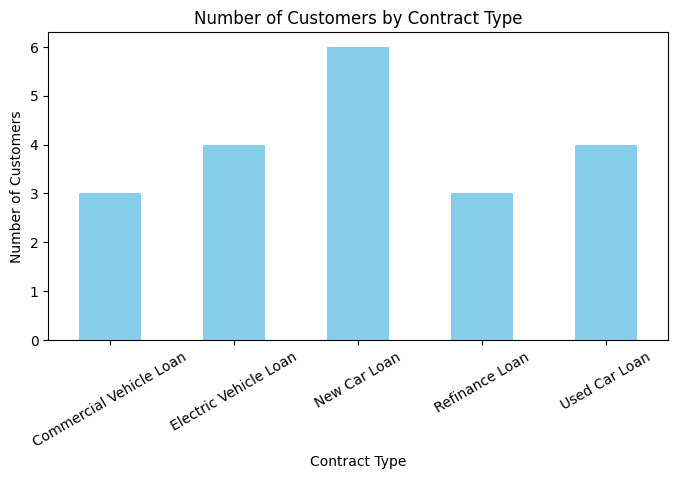

In [6]:
plt.figure(figsize=(8,4))
contracts_count.plot(kind="bar", color="skyblue")
plt.title("Number of Customers by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()


### Average EMI per vehicle_type

In [7]:
avg_emi_vehicle = df.groupby("vehicle_type")["monthly_emi"].mean()
avg_emi_vehicle


vehicle_type
Compact SUV        14500.000000
Crossover SUV      16700.000000
EV Hatchback       12300.000000
EV SUV             16000.000000
EV Sedan           17500.000000
Hatchback           8433.333333
Mini Truck         18900.000000
Pickup Truck       20800.000000
Premium Sedan      24500.000000
SUV                18400.000000
Sedan              11641.666667
Tempo Traveller    22500.000000
Name: monthly_emi, dtype: float64

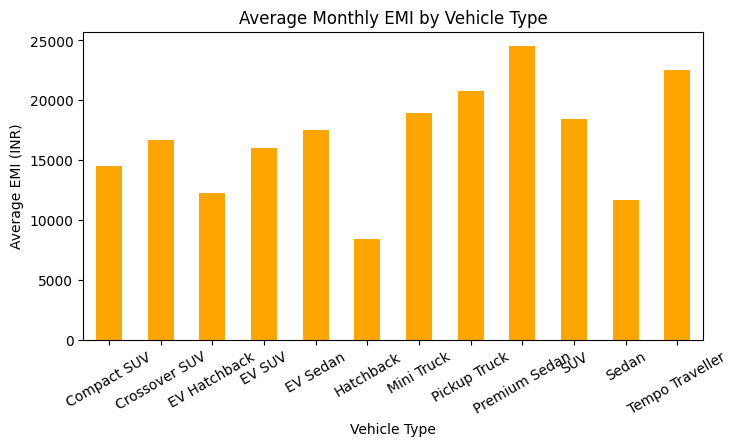

In [8]:
plt.figure(figsize=(8,4))
avg_emi_vehicle.plot(kind="bar", color="orange")
plt.title("Average Monthly EMI by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average EMI (INR)")
plt.xticks(rotation=30)
plt.show()


### Groupby Summary Table

In [9]:
summary = df.groupby("risk_flag").agg({
    "monthly_emi":"mean",
    "interest_rate":"mean",
    "tenure_months":"mean",
    "id":"count"
}).rename(columns={"id":"customer_count"})

summary.round(2)


,monthly_emi,interest_rate,tenure_months,customer_count
risk_flag,,,,
High,15450.00,8.95,68.00,6
Low,12164.29,9.07,48.00,7
Medium,16485.71,10.23,73.71,7


### Scatter Plot

X-axis = tenure_months, 
Y-axis = monthly_emi, 
Color = risk_flag

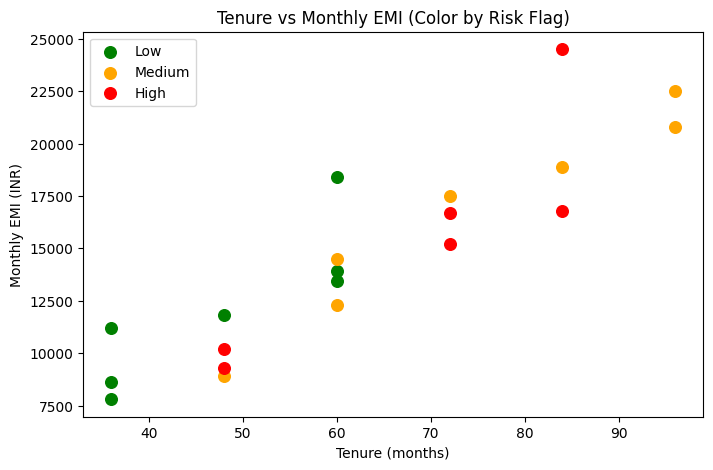

In [10]:
colors = {"Low":"green","Medium":"orange","High":"red"}

plt.figure(figsize=(8,5))
for risk in df["risk_flag"].unique():
    sub = df[df["risk_flag"]==risk]
    plt.scatter(sub["tenure_months"], sub["monthly_emi"], 
                color=colors.get(risk,"blue"), label=risk, s=70)

plt.title("Tenure vs Monthly EMI (Color by Risk Flag)")
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly EMI (INR)")
plt.legend()
plt.show()


This scatter plot was generated showing tenure vs monthly EMI, colored by risk_flag. This plot highlights clusters: high-risk customers often appear in the region of higher EMI and shorter tenures, indicating potentially strained repayment structures.